## Python

In [1]:
import matplotlib.pyplot as plt
from skimage import color
from scipy.ndimage import binary_erosion, binary_dilation
import numpy as np
import cv2
import os
from PIL import Image

### 1. **Carga y visualización de una imagen (RGB) de un animal en via de extinción:**
   - Carga una imagen a color (RGB) desde archivo.
   - Muestra la imagen original en una figura.


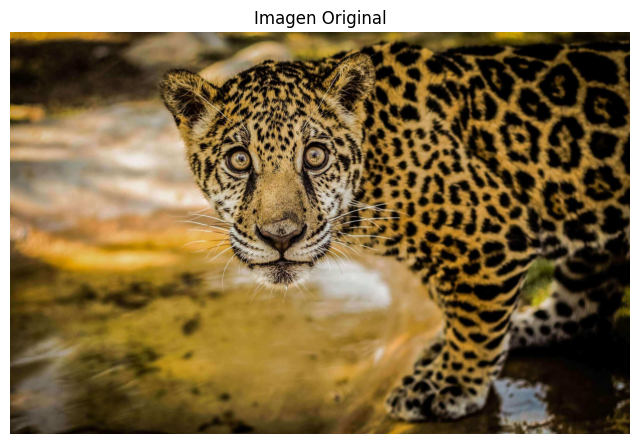

In [2]:
# cargar la imagen y mostrarla en una figura

# Cargar la imagen
image_path = 'data/jaguar.jpg'
image = plt.imread(image_path)

# Mostrar la imagen original
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title('Imagen Original')
plt.axis('off')
plt.show()

### 2. **Filtros básicos:**
   Aplica los siguientes filtros a la imagen :
   - Suavizado / desenfoque
   - Realce de bordes


#### A. Suavizado / Desenfoque

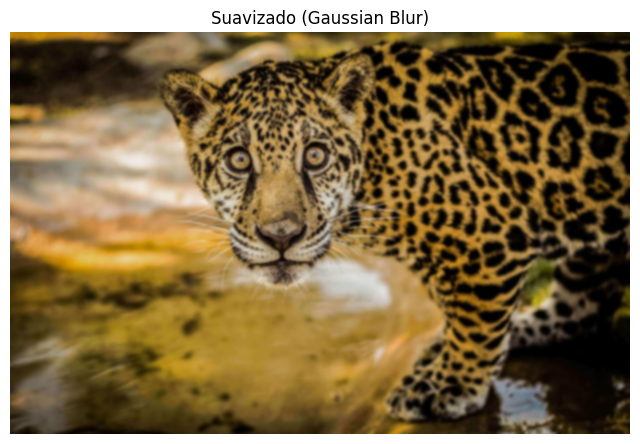

In [3]:
# Desenfoque Gaussiano.
# El kernel (X, X) define la intensidad del suavizado.
X = 25
image_blur = cv2.GaussianBlur(image, (X, X), 0)

plt.figure(figsize=(8, 6))
plt.imshow(image_blur)
plt.title('Suavizado (Gaussian Blur)')
plt.axis('off')
plt.show()

**Análisis del resultado:**
- La imagen parece estar "fuera de foco" o vista a través de un vidrio empañado.
- La textura fina del animal (como los pelos individuales del pelaje o los bigotes) desaparece y se mezcla con los colores vecinos.
- Este tipo de filtro elimina el "ruido" y los detalles pequeños, dejando solo las formas y colores generales.

#### B. Realce de bordes

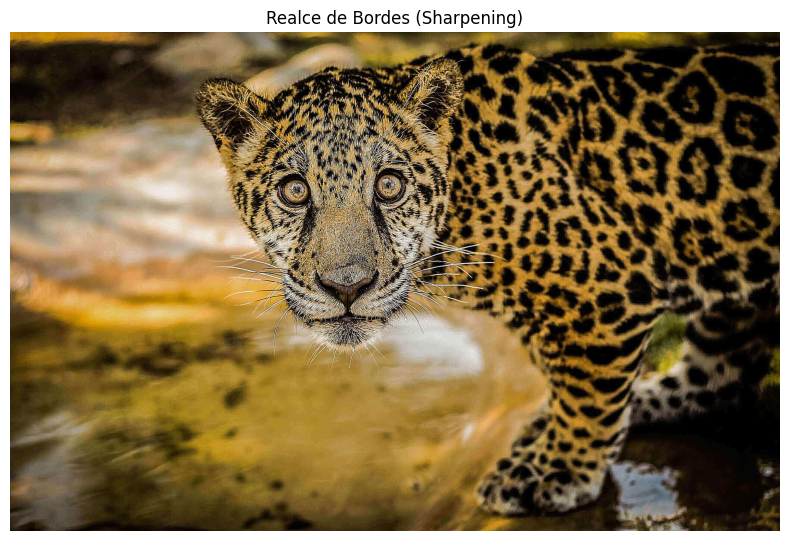

In [4]:
kernel_sharpening = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])

# Aplicamos el filtro utilizando filter2D
image_sharpened = cv2.filter2D(image, -1, kernel_sharpening)

plt.figure(figsize=(8, 6))
plt.imshow(image_sharpened)
plt.title('Realce de Bordes (Sharpening)')
plt.axis('off')

plt.tight_layout()
plt.show()

**Análisis del resultado:**
- La imagen se vuelve más granulada y con un contraste agresivo.
- Las manchas del jaguar y los contornos de la figura se separan drásticamente del fondo. Sin embargo, es posible que la imagen se vea un poco "granulada" o artificial.
- Este filtro exagera los cambios de luz para hacer que los límites de los objetos sean inconfundibles.

### 3. **Visualización de canales de color:**
- Separa la imagen original en sus tres canales (R, G, B).
- Muestra en una figura:
  - Los tres canales en escala de grises (cada canal por separado).
- Explica brevemente qué estructuras se ven más claras u oscuras en cada canal y por qué.



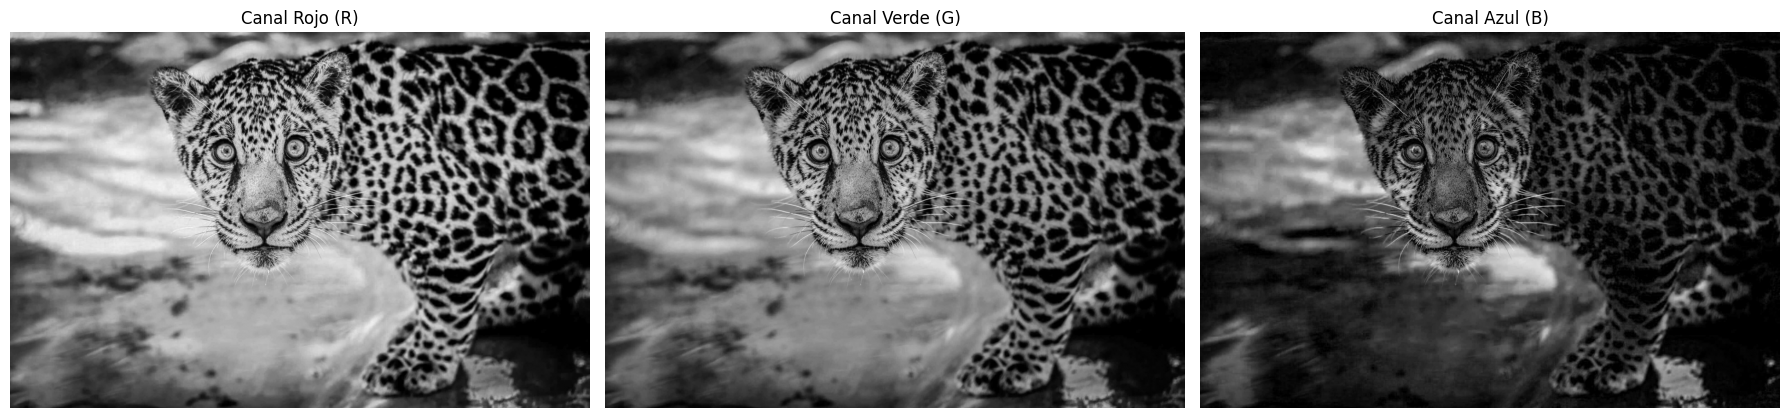

In [5]:
# 1. Separar los canales
# Canal 0 = Rojo (R), Canal 1 = Verde (G), Canal 2 = Azul (B)
canal_rojo = image[:, :, 0]
canal_verde = image[:, :, 1]
canal_azul = image[:, :, 2]

# 2. Visualización en una sola figura con 3 sub-gráficos
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Canal Rojo
ax[0].imshow(canal_rojo, cmap='gray')
ax[0].set_title('Canal Rojo (R)')
ax[0].axis('off')

# Canal Verde
ax[1].imshow(canal_verde, cmap='gray')
ax[1].set_title('Canal Verde (G)')
ax[1].axis('off')

# Canal Azul
ax[2].imshow(canal_azul, cmap='gray')
ax[2].set_title('Canal Azul (B)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

**Explicación de los canales**
- Canal Rojo: Se ve brillante, es el que más tiene peso en la imagen del jaguar. Esto sucede dado que el color amarillo del jaguar se forma con mucha luz roja. Por lo tanto, el sensor capta valores altos en este canal para la piel del animal.
- Canal Verde: Este canal también se ve claro, dado que el amarillo en las imagenes es una mezcla de colores rojo y verde. Además, las plantas reflejan verde, por lo que el fondo vegetal también tiene intensidad media-alta aquí.
- Canal Azul: El color amarillo es, por definición, opuesto al azul. El pelaje absorbe la luz azul y refleja la roja + verde. Por tanto, hay poca "información azul" en la imagen del animal, resultando en píxeles oscuros. Este es el canal más oscuro.

### 4. Operaciones morfológicas :
   - Trabaja sobre una versión en escala de grises o binarizada de la imagen.
   - Aplica dos operaciones morfológicas diferentes

   - Muestra los resultados comparando:
     - Imagen original (o binarizada).
     - Imagen después de cada operación.
   - Explica brevemente que efecto tuvo la operación sobre la imagen

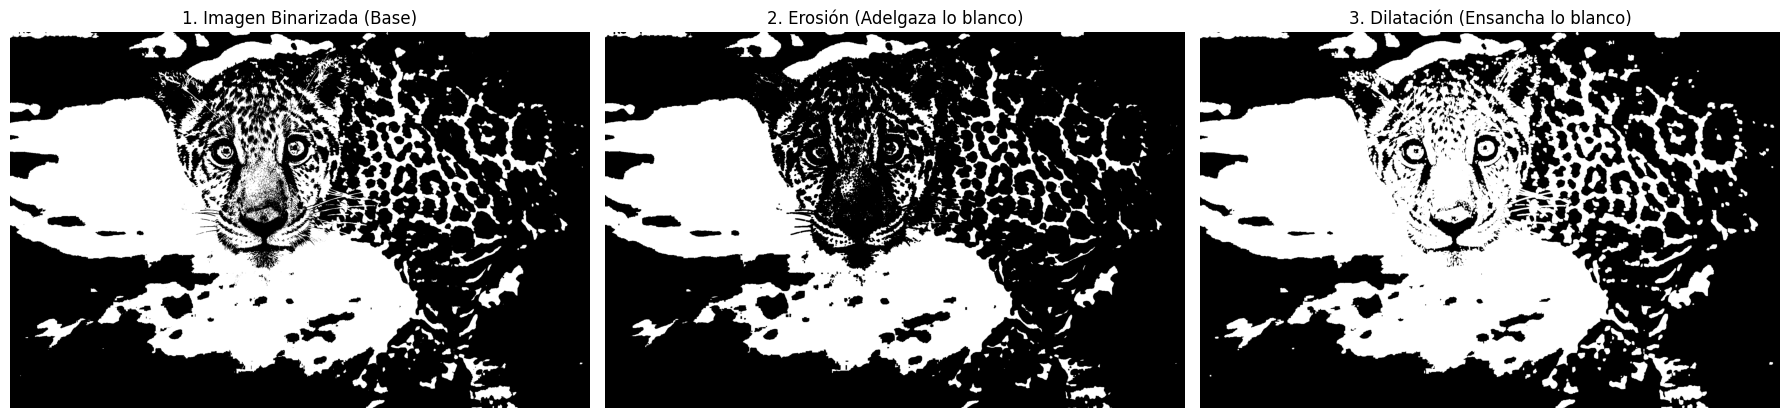

In [6]:
# 1. Preprocesamiento: Convertir a Escala de Grises y luego a Binaria
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Aplicamos un umbral (Threshold) para binarizar
# Los píxeles claros (pelaje) se vuelven 255 (Blanco), los oscuros (manchas) 0 (Negro)
_, image_binary = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)

# 2. Definir el Kernel (la forma que "escanea" la imagen)
# Un cuadrado de 5x5 píxeles
X = 5
kernel = np.ones((X, X), np.uint8)

# 3. Aplicar Operaciones Morfológicas

# A. Erosión (Erode): "Come" o reduce las zonas blancas
image_erosion = cv2.erode(image_binary, kernel, iterations=1)

# B. Dilatación (Dilate): "Expande" o agranda las zonas blancas
image_dilation = cv2.dilate(image_binary, kernel, iterations=1)

# 4. Visualización Comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagen Binarizada Base
axes[0].imshow(image_binary, cmap='gray')
axes[0].set_title('1. Imagen Binarizada (Base)')
axes[0].axis('off')

# Resultado Erosión
axes[1].imshow(image_erosion, cmap='gray')
axes[1].set_title('2. Erosión (Adelgaza lo blanco)')
axes[1].axis('off')

# Resultado Dilatación
axes[2].imshow(image_dilation, cmap='gray')
axes[2].set_title('3. Dilatación (Ensancha lo blanco)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


**Análisis de resultados:**
- Erosión: El algoritmo recorre la imagen y reduce el perímetro de las zonas blancas. Al reducirse el blanco (el pelaje), las manchas negras y el fondo se ven más grandes y gruesas. Si hubiera pequeños puntos de ruido blanco, desaparecerían.
- Dilatación: El algoritmo expande las zonas blancas hacia afuera. Al expandirse el blanco (el pelaje), las manchas negras se hacen más pequeñas o incluso desaparecen si son muy finas. Esto sirve para "rellenar" agujeros negros dentro de un objeto blanco.

### 5. Animación:
- Genera una animación simple  o creando un GIF a partir de varios frames donde se vea:
    - La imagen original.
    - Los resultados de los filtros y/o operaciones morfológicas de forma secuencial.


In [7]:
output_folder = 'gifs'

def guardar_frame_matplotlib(img_data, title, temp_filename, cmap=None):
    """
    Función auxiliar para convertir un array numpy en una imagen guardada
    con título y formato de Matplotlib, lista para ser un frame del GIF.
    """
    plt.figure(figsize=(8, 6))
    if cmap:
        plt.imshow(img_data, cmap=cmap)
    else:
        plt.imshow(img_data)
    
    plt.title(title, fontsize=15, fontweight='bold')
    plt.axis('off')
    
    # Guardamos temporalmente el frame
    path = os.path.join(output_folder, temp_filename)
    plt.savefig(path, bbox_inches='tight', pad_inches=0.1)
    plt.close() # Cerramos para liberar memoria
    return path

def crear_gif(lista_frames, nombre_gif, duracion=1000):
    """
    Toma una lista de rutas de imágenes y genera un GIF.
    duracion: Tiempo en milisegundos por frame.
    """
    images = [Image.open(f) for f in lista_frames]
    gif_path = os.path.join(output_folder, nombre_gif)
    
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=duracion,
        loop=0 # 0 significa loop infinito
    )
    print(f" GIF generado exitosamente: {gif_path}")
    
    # Limpieza de archivos temporales (opcional)
    for f in lista_frames:
        os.remove(f)

# --- 1. GENERAR GIF DE FILTROS ---
print("Generando GIF de filtros...")
frames_filtros = []

# Definimos la secuencia: (Imagen, Título, Nombre_archivo_temporal)
secuencia_filtros = [
    (image, "1. Imagen Original", "temp_1.png"),
    (image_blur, "2. Filtro: Suavizado Gaussiano", "temp_2.png"),
    (image_sharpened, "3. Filtro: Realce de Bordes", "temp_3.png")
]

# Generamos los frames
for img, tit, fname in secuencia_filtros:
    path = guardar_frame_matplotlib(img, tit, fname)
    frames_filtros.append(path)

# Creamos el GIF
crear_gif(frames_filtros, "animacion_filtros.gif", duracion=1200)


# --- 2. GENERAR GIF DE MORFOLOGÍA (Binario) ---
print("Generando GIF de morfología...")
frames_morfologia = []

secuencia_morfologia = [
    (image_binary, "1. Binarización (Threshold)", "temp_m1.png"),
    (image_erosion, "2. Operación: Erosión", "temp_m2.png"),
    (image_dilation, "3. Operación: Dilatación", "temp_m3.png")
]

for img, tit, fname in secuencia_morfologia:
    # Nota: Usamos cmap='gray' para las binarias
    path = guardar_frame_matplotlib(img, tit, fname, cmap='gray')
    frames_morfologia.append(path)

crear_gif(frames_morfologia, "animacion_morfologia.gif", duracion=1200)


# --- 3. GENERAR GIF DE RGB ---
print("Generando GIF RGB...")
frames_RGB = []

# generamos los frames
secuencia_RGB = [
    (canal_rojo, "Canal Rojo R","temp_f1.png"),
    (canal_verde, "Canal Verde G","temp_f2.png"),
    (canal_azul, "Canal Azul B","temp_f3.png")
]

for img, tit, fname in secuencia_RGB:
    # Nota: Usamos cmap='gray' para las binarias
    path = guardar_frame_matplotlib(img, tit, fname, cmap='gray')
    frames_RGB.append(path)

# Creamos el GIF
crear_gif(frames_RGB, "animacion_canalesRGB.gif", duracion=1200)

Generando GIF de filtros...
 GIF generado exitosamente: gifs\animacion_filtros.gif
Generando GIF de morfología...
 GIF generado exitosamente: gifs\animacion_morfologia.gif
Generando GIF RGB...
 GIF generado exitosamente: gifs\animacion_canalesRGB.gif
